In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import json
from src.io.io import (
    load_battles_from_json,
)

from src.optimizers.battle_model import (
    fit_model,
    summarize_params,
    evaluate_model,
)

from src.optimizers.battle_model import NO_SKILL_HEROES, build_hero_index, fit_model

NO_SKILL_HEROES.update({"Smith", "Jina", "Cloris", "Eugene", "Lumak Bokan", "Co-June", "Charlie"})   # add any hero without battle skills

In [11]:
hero_roles = {
    "Alonso": "marksman",
    "Cloris": "marksman",
    "Bakhiti": "marksman",
    "Jina": "marksman",
    "Logan": "marksman",
    "Co-June": "marksman",
    "Zinman": "marksman",
    "Sergei": "infantry",
    "Geronimo": "infantry",
    "Flint": "infantry",
    "Greg": "infantry",
    "Natalia": "infantry",
    "Eugene": "infantry",
    "Smith": "infantry",
    "Mia": "lancer",
    "Molly": "lancer",
    "Filly": "lancer",
    "Jessi": "lancer",
    "Charlie": "lancer",
    "Patrik": "lancer",
    "Jasper": "lancer",
    "Lumak Bokan": "lancer",
    "Lin Sue": "lancer"
}

In [21]:
battles = load_battles_from_json("./data")

Loaded 85 battles.

  ID   Outcome          Blue           Red  Blue heroes                     Red heroes                    
---------------------------------------------------------------------------------------------------------
   3      LOSE    -1,284,177      -311,717  Sergei, Patrik, Jina            Flint, Molly, Alonso          
   4      LOSE   -10,839,894    -2,706,817  Geronimo, Molly, Alonso         Geronimo, Filly, Alonso       
   5      LOSE    -4,887,870      -330,260  Flint, Mia, Alonso              Geronimo, Mia, Alonso         
   6      LOSE    -3,804,075      -701,485  Sergei, Molly, Bakhiti          Flint, Patrik, Alonso         
   7      LOSE    -3,804,075    -1,370,610  Flint, Mia, Alonso              Geronimo, Molly, Alonso       
   8      LOSE    -4,887,870    -1,035,674  Flint, Mia, Alonso              Geronimo, Mia, Alonso         
   9      LOSE   -29,368,049    -2,550,502  Geronimo, Mia, Alonso           Geronimo, Mia, Greg           
  10      LOSE   -

In [36]:
[h.name for h in battles[0].blue.heroes]

['Sergei', 'Patrik', 'Jina']

In [38]:
from collections import Counter

hero_battle_counts = Counter()
for b in battles:
    
    red_heroes = set(h.name for h in b.red.heroes)
    blue_heroes = set(h.name for h in b.blue.heroes)
    for hero in blue_heroes | red_heroes:
        hero_battle_counts[hero] += 1

print(f"{'Hero':<20}  {'Battles':>7}")
print("-" * 30)
hero_counts = {}
for hero, count in sorted(hero_battle_counts.items(), key=lambda x: -x[1]):
    hero_counts[hero] = count
    print(f"{hero:<20}  {count:>7}")

Hero                  Battles
------------------------------
Alonso                     66
Mia                        65
Geronimo                   45
Flint                      29
Greg                       21
Molly                      17
Patrik                     16
Bakhiti                    15
Jina                       12
Logan                      12
Jessi                      12
Sergei                     11
Smith                      10
Eugene                      9
Cloris                      9
Natalia                     7
Filly                       6
Jasper                      5
Charlie                     4
Lumak Bokan                 2
Co-June                     1
Lin Sue                     1
Zinman                      1


In [39]:
selected_heroes = set(hero for hero, count in hero_counts.items() if count >= 10)

In [51]:
battles_selected = [b for b in battles if (all(hero.name in selected_heroes for hero in b.blue.heroes) and all(hero.name in selected_heroes for hero in b.red.heroes))]

In [52]:
len(battles_selected)

61

In [53]:
params, nll, hero_index = fit_model(battles_selected, n_restarts=1)

Heroes: ['Alonso', 'Bakhiti', 'Flint', 'Geronimo', 'Greg', 'Jessi', 'Jina', 'Logan', 'Mia', 'Molly', 'Patrik', 'Sergei', 'Smith']
Parameters: 33  |  Battles: 61

Restart  1: NLL = 0.0000  converged=True


In [4]:
np.save("./settings/battle_params", params)
with open("./settings/battle_heroes.json", "w", encoding="utf-8") as f:
    json.dump(hero_index, f, indent=4, ensure_ascii=False)

In [54]:
summarize_params(params, hero_index)
evaluate_model(battles, params, hero_index)

=== Structural parameters ===
  delta (army scale)   : 0.7582
  alpha (B_off power)  : 1.9360
  beta  (B_def power)  : 1.0068
  w_inf / w_spr / w_arc: 0.412 / 0.187 / 0.401
  kappa (margin scale) : 1.0992

=== Hero coefficients ===
    hero  beta_off  beta_def
  Alonso    0.4811    0.4846
 Bakhiti    0.5054    0.4980
   Flint    0.5205    0.5149
Geronimo    0.4952    0.5079
    Greg    0.5245    0.5260
   Jessi    0.5133    0.5098
    Jina    0.4909    0.4883
   Logan    0.4925    0.4908
     Mia    0.5003    0.5050
   Molly    0.4818    0.4768
  Patrik    0.5067    0.5057
  Sergei    0.4809    0.4744
   Smith    0.5133    0.5098

Accuracy    : 0.976
Mean NLL    : 0.3565
Brier score : 0.0247

 battle_id  outcome  p_win     margin  correct
         3        0 0.0000   -18.7721        1
         4        0 0.0000   -62.4244        1
         5        0 0.0000  -498.2521        1
         6        0 0.0000    -6.1082        1
         7        0 0.0000   -40.4565        1
         8      

,battle_id,outcome,p_win,margin,correct
0,3,0,0.0000,-18.7721,1
1,4,0,0.0000,-62.4244,1
2,5,0,0.0000,-498.2521,1
3,6,0,0.0000,-6.1082,1
4,7,0,0.0000,-40.4565,1
...,...,...,...,...,...
80,83,1,1.0000,32.4677,1
81,84,1,1.0000,30.2433,1
82,85,0,0.0000,-18.5445,1
83,86,1,1.0000,16.1526,1


## Casualty model

Predicts the **casualty rate** (wounded + lightly wounded) / N for each side.

**Key design choices**
- Structural parameters (δ, α, β, w, hero β) are **fixed** from the win model.
- **Winning side** — regression model estimates the casualty rate using five predictors:
  - `pressure = OFF_opponent / DEF_self` — incoming damage *per capita* (bonus-weighted).
  - `counter_pressure = DEF_opponent / OFF_self` — how well the opponent resists.
  - `size_ratio = N_opponent / N_self` — numerical head-count disadvantage.
  - `opp_inf_share` — opponent's infantry fraction (type-lethality correction vs archer baseline).
  - `opp_spr_share` — opponent's spearman fraction (type-lethality correction vs archer baseline).
  - Functional form: `logit(cas_rate) = a + b·log(pressure) + c·log(counter_pressure) + d·log(size_ratio) + e·opp_inf + f·opp_spr`
  - Fitted by OLS on non-censored observations (winning side, `survivors > 0`).
- **Losing side** — fully wiped out (`cas_rate = 1.0`); wounded/lightly-wounded split applied directly with `WOUNDED_SHARE = 0.35`.
- Game constant: `wounded / total_casualties ≈ 0.35` → split is fixed post-prediction.

**Why type-share terms were added**
`pressure` is a *bonus-weighted* scalar: it captures how much the opponent's investment in attack bonuses translates to damage, but not whether their troop type is inherently more or less lethal in terms of casualties. Empirically, infantry-heavy attackers cause fewer casualties than archer-heavy ones at the same pressure level (likely because archers have higher base damage rate). The two type-share terms correct for this and lift adjusted R² from ≈0.68 to ≈0.69.

**Model history** (winning side, adjusted R²):
| Predictors | adj R² | MAE |
|---|---|---|
| pressure only | 0.44 | 0.115 |
| + counter_pressure | 0.59 | 0.092 |
| + size_ratio | 0.68 | 0.086 |
| + opp_inf + opp_spr | 0.69 | ~0.082 |

In [63]:
from scipy import stats as scipy_stats
from dataclasses import asdict as dc_asdict
from src.optimizers.casualty_model import (
    fit_casualty_model,
    evaluate_casualty_model,
    save_casualty_params,
    compute_pressure,
    compute_counter_pressure,
    compute_size_ratio,
    opponent_type_shares,
    CasualtyParams,
    WOUNDED_SHARE,
)

# ── Collect non-censored observations for OLS ─────────────────────────────────
X_pressure_vals, X_counter_vals, X_size_vals, X_inf_vals, X_spr_vals, y_vals = [], [], [], [], [], []

for b in battles:
    for side, opp in [(b.blue, b.red), (b.red, b.blue)]:
        oc = side.outcome_stats
        if oc is None:
            continue
        total_cas = (oc.losses or 0) + (oc.wounded or 0) + (oc.lightly_wounded or 0)
        if total_cas == 0 or side.N == 0:
            continue
        cas_rate = total_cas / side.N
        if cas_rate >= 1.0:
            continue  # censored

        pressure = compute_pressure(side, opp, params, hero_index)
        counter_pressure = compute_counter_pressure(side, opp, params, hero_index)
        size_ratio = compute_size_ratio(side, opp)
        opp_inf, opp_spr = opponent_type_shares(opp)
        X_pressure_vals.append(np.log(pressure))
        X_counter_vals.append(np.log(counter_pressure))
        X_size_vals.append(np.log(size_ratio))
        X_inf_vals.append(opp_inf)
        X_spr_vals.append(opp_spr)
        y_vals.append(np.log(cas_rate / (1.0 - cas_rate)))  # logit

X_p  = np.array(X_pressure_vals)
X_c  = np.array(X_counter_vals)
X_s  = np.array(X_size_vals)
X_i  = np.array(X_inf_vals)
X_sp = np.array(X_spr_vals)
y = np.array(y_vals)
n, k = len(y), 6

# ── OLS ───────────────────────────────────────────────────────────────────────
X_mat = np.column_stack([np.ones(n), X_p, X_c, X_s, X_i, X_sp])
XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
beta = XtX_inv @ (X_mat.T @ y)
y_hat = X_mat @ beta
resid = y - y_hat

RSS   = float(resid @ resid)
TSS   = float(((y - y.mean()) ** 2).sum())
R2    = 1.0 - RSS / TSS
adjR2 = 1.0 - (1.0 - R2) * (n - 1) / (n - k)
s2    = RSS / (n - k)
SE    = np.sqrt(np.diag(s2 * XtX_inv))
t_st  = beta / SE
p_val = 2.0 * (1.0 - scipy_stats.t.cdf(np.abs(t_st), df=n - k))
ci_lo = beta - scipy_stats.t.ppf(0.975, df=n - k) * SE
ci_hi = beta + scipy_stats.t.ppf(0.975, df=n - k) * SE
F_stat = ((TSS - RSS) / (k - 1)) / (RSS / (n - k))
F_p    = 1.0 - scipy_stats.f.cdf(F_stat, k - 1, n - k)

# ── Regression table ──────────────────────────────────────────────────────────
SEP = "=" * 82
print(SEP)
print("  Casualty Model — OLS")
print("  Dependent variable : logit(cas_rate)  |  winning side only")
print("  Regressors         : intercept, log(pressure), log(counter_pressure),")
print("                       log(size_ratio), opp_inf_share, opp_spr_share")
print("  Note: opp_arc_share is the omitted baseline for type-lethality terms")
print(SEP)
print(f"  Observations (non-censored) : {n}")
print(f"  R²                          : {R2:.4f}")
print(f"  Adjusted R²                 : {adjR2:.4f}")
print(f"  Residual std (logit scale)  : {np.sqrt(s2):.4f}")
print(f"  F({k-1}, {n-k})                    : {F_stat:.3f}  (p = {F_p:.4f})")
print()
hdr = f"  {'Parameter':<30}  {'Coef':>9}  {'Std Err':>9}  {'t':>7}  {'P>|t|':>7}  {'[0.025':>9}  {'0.975]':>9}"
print(hdr)
print("-" * 82)
names = ["a  (intercept)", "b  (log-pressure)", "c  (log-counter-pressure)",
         "d  (log-size-ratio)", "e  (opp_inf_share)", "f  (opp_spr_share)"]
for nm, c, se, t, p, lo, hi in zip(names, beta, SE, t_st, p_val, ci_lo, ci_hi):
    stars = " ***" if p < 0.001 else " **" if p < 0.01 else " *" if p < 0.05 else "    "
    print(f"  {nm:<30}  {c:>9.4f}  {se:>9.4f}  {t:>7.3f}  {p:>7.4f}  {lo:>9.4f}  {hi:>9.4f}{stars}")
print(SEP)
print("  Significance: *** p<0.001  ** p<0.01  * p<0.05")
print()
print("  Type-lethality interpretation (relative to archers as baseline):")
inf_coef, spr_coef = float(beta[4]), float(beta[5])
print(f"    infantry : {inf_coef:+.3f}  →  {'lower' if inf_coef < 0 else 'higher'} casualties than archer-heavy opponents")
print(f"    spearman : {spr_coef:+.3f}  →  {'lower' if spr_coef < 0 else 'higher'} casualties than archer-heavy opponents")

# ── Goodness-of-fit on original cas_rate scale ────────────────────────────────
from scipy.special import expit
pred_rates   = expit(y_hat)
actual_rates = expit(y)
mae  = float(np.abs(pred_rates - actual_rates).mean())
rmse = float(np.sqrt(((pred_rates - actual_rates) ** 2).mean()))
print()
print(f"  MAE  (cas_rate scale, non-censored) : {mae:.4f}")
print(f"  RMSE (cas_rate scale, non-censored) : {rmse:.4f}")

# Store fitted params
cas_params = CasualtyParams(
    intercept=float(beta[0]),
    pressure_coef=float(beta[1]),
    counter_pressure_coef=float(beta[2]),
    size_ratio_coef=float(beta[3]),
    opp_inf_coef=float(beta[4]),
    opp_spr_coef=float(beta[5]),
)

  Casualty Model — OLS
  Dependent variable : logit(cas_rate)  |  winning side only
  Regressors         : intercept, log(pressure), log(counter_pressure),
                       log(size_ratio), opp_inf_share, opp_spr_share
  Note: opp_arc_share is the omitted baseline for type-lethality terms
  Observations (non-censored) : 85
  R²                          : 0.7089
  Adjusted R²                 : 0.6905
  Residual std (logit scale)  : 0.8857
  F(5, 79)                    : 38.484  (p = 0.0000)

  Parameter                            Coef    Std Err        t    P>|t|     [0.025     0.975]
----------------------------------------------------------------------------------
  a  (intercept)                    -2.6956     0.6099   -4.420   0.0000    -3.9095    -1.4817 ***
  b  (log-pressure)                  0.9837     0.1055    9.324   0.0000     0.7737     1.1937 ***
  c  (log-counter-pressure)          0.2909     0.0921    3.158   0.0022     0.1076     0.4742 **
  d  (log-size-ratio)   

In [7]:
save_casualty_params(cas_params, "./settings/casualty_params.json")
print("Saved → ./settings/casualty_params.json")

Saved → ./settings/casualty_params.json


In [68]:
import pandas as pd
from src.optimizers.casualty_model import predict_casualties

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:.4f}".format)

rows = []
for b in battles:
    winner = "Blue" if b.outcome == 1 else "Red"
    for side_name, side, opp in [("Blue", b.blue, b.red), ("Red", b.red, b.blue)]:
        oc = side.outcome_stats
        if oc is None:
            continue
        actual_cas   = (oc.losses or 0) + (oc.wounded or 0) + (oc.lightly_wounded or 0)
        actual_rate  = actual_cas / side.N if side.N > 0 else float("nan")
        censored     = actual_rate >= 1.0

        pred = predict_casualties(side, opp, params, hero_index, cas_params, won=(side_name == winner))

        rows.append({
            "battle": b.battle_id,
            "side":   side_name,
            "result": "WIN" if side_name == winner else "lose",
            "N":      int(side.N),
            "Pressure": compute_pressure(side, opp, params, hero_index),
            "CounterPressure": compute_counter_pressure(side, opp, params, hero_index),
            "SizeRatio": compute_size_ratio(side, opp),
            # ── actual ──────────────────────────────
            "act_cas_rate":  round(actual_rate, 4),
            "act_cas":       actual_cas,
            "act_wounded":   oc.wounded or 0,
            "act_lgt_wnd":   oc.lightly_wounded or 0,
            # ── predicted ───────────────────────────
            "pred_cas_rate": round(pred.cas_rate, 4),
            "pred_cas":      pred.total_casualties,
            "pred_wounded":  pred.wounded,
            "pred_lgt_wnd":  pred.lightly_wounded,
            # ── residual ────────────────────────────
            "err_rate":  round(pred.cas_rate - actual_rate, 4),
            "censored":  censored,
        })

df_eval = pd.DataFrame(rows)

# Summary stats
non_cens = df_eval[~df_eval["censored"]]
cens     = df_eval[df_eval["censored"]]
mae_nc   = non_cens["err_rate"].abs().mean()
rmse_nc  = (non_cens["err_rate"] ** 2).mean() ** 0.5
mae_c    = (cens["pred_cas_rate"] - 1.0).abs().mean()

print("────────────────────────────────────────────────────────────────")
print(f"  Non-censored (winners)  n={len(non_cens):>2}   MAE={mae_nc:.4f}   RMSE={rmse_nc:.4f}")
print(f"  Censored     (losers)   n={len(cens):>2}   pred always 1.0  (MAE vs actual = {mae_c:.4f})")
print("────────────────────────────────────────────────────────────────")
print()

df_eval

────────────────────────────────────────────────────────────────
  Non-censored (winners)  n=85   MAE=0.0878   RMSE=0.1304
  Censored     (losers)   n=85   pred always 1.0  (MAE vs actual = 0.0000)
────────────────────────────────────────────────────────────────



,battle,side,result,N,Pressure,CounterPressure,SizeRatio,act_cas_rate,act_cas,act_wounded,act_lgt_wnd,pred_cas_rate,pred_cas,pred_wounded,pred_lgt_wnd,err_rate,censored
0,3,Blue,lose,40189,25.1351,0.1241,2.8661,1.0000,40189,18087,22102,1.0000,40189,14066,26123,0.0000,True
1,3,Red,WIN,115184,8.0568,0.0398,0.3489,0.1528,17599,6160,11439,0.1076,12394,4338,8056,-0.0452,False
2,4,Blue,lose,605758,76.1325,0.0517,1.4445,1.0000,605758,181734,424024,1.0000,605758,212015,393743,0.0000,True
3,4,Red,WIN,875029,19.3404,0.0131,0.6923,0.1872,163834,49157,114677,0.1992,174288,61001,113287,0.0119,False
4,5,Blue,lose,168252,456.9737,0.2720,4.5139,1.0000,168252,58890,109362,1.0000,168252,58888,109364,0.0000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,85,Red,WIN,127910,9.9313,0.0373,1.0985,0.2242,28679,8605,20074,0.2194,28067,9823,18244,-0.0048,False
166,86,Blue,WIN,140510,14.9975,0.0337,0.9103,0.3385,47564,14270,33294,0.1904,26757,9365,17392,-0.1481,False
167,86,Red,lose,127910,29.6927,0.0667,1.0985,1.0000,127910,38374,89536,1.0000,127910,44768,83142,0.0000,True
168,87,Blue,lose,140510,31.0282,0.0677,0.9630,1.0000,140510,49179,91331,1.0000,140510,49178,91332,0.0000,True


In [71]:
df_eval.sort_values("err_rate", key=lambda col: col.abs(), ascending=False).head(10)

,battle,side,result,N,Pressure,CounterPressure,SizeRatio,act_cas_rate,act_cas,act_wounded,act_lgt_wnd,pred_cas_rate,pred_cas,pred_wounded,pred_lgt_wnd,err_rate,censored
102,54,Blue,WIN,76188,20.6530,0.0369,1.7734,0.9601,73145,21945,51200,0.4749,36181,12663,23518,-0.4852,False
148,77,Blue,WIN,128907,12.0796,0.0503,0.9854,0.5408,69713,24401,45312,0.2413,31109,10888,20221,-0.2995,False
158,82,Blue,WIN,100768,15.9512,0.0796,0.9529,0.5903,59486,20821,38665,0.2971,29943,10480,19463,-0.2932,False
156,81,Blue,WIN,140470,20.5227,0.0795,0.8059,0.1802,25310,8859,16451,0.4647,65270,22844,42426,0.2845,False
41,23,Red,WIN,1084500,79.8281,0.0075,1.0177,0.7708,835942,292589,543353,0.4966,538579,188503,350076,-0.2742,False
151,78,Red,WIN,66071,12.6273,0.0258,2.0003,0.0880,5817,1746,4071,0.3602,23799,8330,15469,0.2722,False
111,58,Red,WIN,134710,4.3802,0.0161,0.9431,0.3399,45785,16026,29759,0.0786,10585,3705,6880,-0.2613,False
29,17,Red,WIN,805489,85.2579,0.0063,1.3703,0.3080,248083,86835,161248,0.5688,458125,160344,297781,0.2608,False
71,38,Red,WIN,973111,74.5024,0.0051,1.1342,0.2168,211003,73855,137148,0.4758,463046,162066,300980,0.2590,False
126,66,Blue,WIN,140510,2.4701,0.0061,1.0299,0.3095,43494,13049,30445,0.0515,7232,2531,4701,-0.2581,False


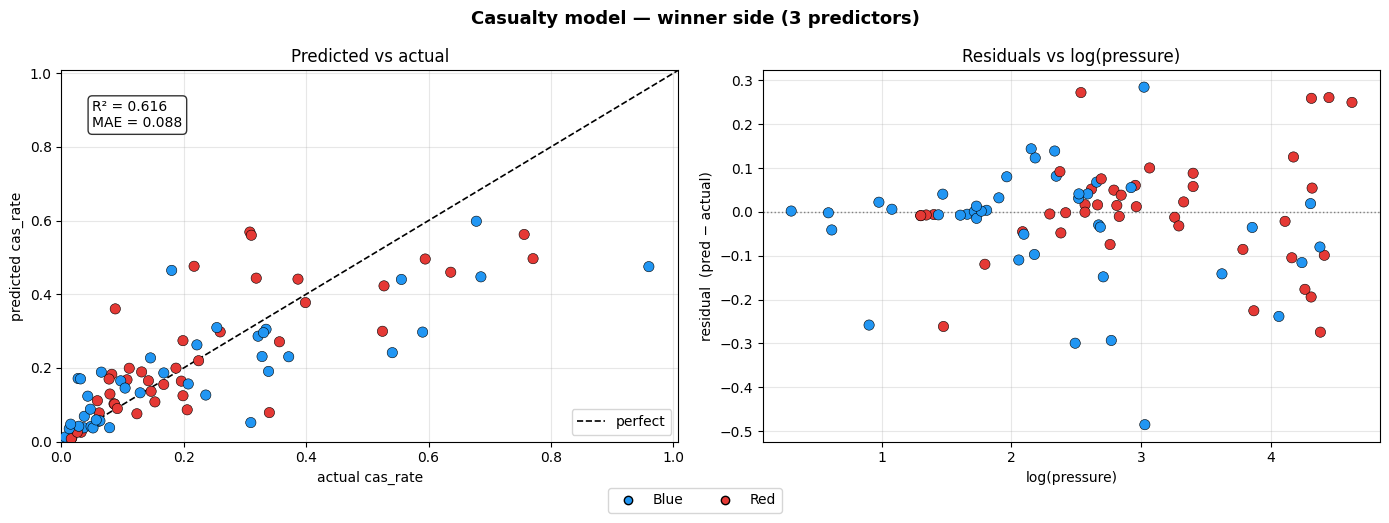

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import expit

# ── Collect winner (non-censored) observations with full model prediction ─────
log_p, pred_r, act_r, sides = [], [], [], []
for b in battles:
    winner = "Blue" if b.outcome == 1 else "Red"
    for side_name, side, opp in [("Blue", b.blue, b.red), ("Red", b.red, b.blue)]:
        oc = side.outcome_stats
        if oc is None or side.N == 0:
            continue
        total_cas = (oc.losses or 0) + (oc.wounded or 0) + (oc.lightly_wounded or 0)
        cas_rate = total_cas / side.N
        if cas_rate >= 1.0:        # losers are deterministic (=1.0), skip
            continue
        pred = predict_casualties(side, opp, params, hero_index, cas_params, won=(side_name == winner))
        log_p.append(np.log(compute_pressure(side, opp, params, hero_index)))
        pred_r.append(pred.cas_rate)
        act_r.append(cas_rate)
        sides.append(side_name)

log_p = np.array(log_p); pred_r = np.array(pred_r); act_r = np.array(act_r)
palette = {"Blue": "#2196F3", "Red": "#E53935"}
colors = [palette[s] for s in sides]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Casualty model — winner side (3 predictors)", fontsize=13, fontweight="bold")

# ── Panel 1: predicted vs actual ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(act_r, pred_r, c=colors, s=55, zorder=3, edgecolors="k", linewidths=0.4)
lims = [0, max(act_r.max(), pred_r.max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1.2, label="perfect")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("actual cas_rate"); ax.set_ylabel("predicted cas_rate")
ax.set_title("Predicted vs actual"); ax.grid(True, alpha=0.3); ax.legend()
r2 = 1.0 - ((act_r - pred_r) ** 2).sum() / ((act_r - act_r.mean()) ** 2).sum()
ax.text(0.05, 0.92, f"R² = {r2:.3f}\nMAE = {np.abs(pred_r - act_r).mean():.3f}",
        transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# ── Panel 2: residuals vs log(pressure) ───────────────────────────────────────
ax = axes[1]
ax.scatter(log_p, pred_r - act_r, c=colors, s=55, zorder=3, edgecolors="k", linewidths=0.4)
ax.axhline(0, color="grey", lw=1.0, ls=":")
ax.set_xlabel("log(pressure)"); ax.set_ylabel("residual  (pred − actual)")
ax.set_title("Residuals vs log(pressure)"); ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=palette[s], mec="k", label=s) for s in ("Blue", "Red")]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

In [77]:
summarize_params(joint_params, hero_index)


=== Structural parameters ===
  delta (army scale)   : 0.5965
  alpha (B_off power)  : 1.8327
  beta  (B_def power)  : 0.8946
  w_inf / w_spr / w_arc: 0.431 / 0.354 / 0.215
  kappa (margin scale) : 172.4887

=== Hero coefficients ===
    hero  beta_off  beta_def
  Alonso    0.4655    0.0396
 Bakhiti    0.6527    0.9528
   Flint    0.5984    0.9326
Geronimo    0.9979    0.8595
    Greg    0.9880    0.8210
   Jessi    0.0559    0.5294
    Jina    0.0092    0.6507
   Logan    0.9985    0.9576
     Mia    0.9994    0.4266
   Molly    0.0124    0.6067
  Patrik    0.0728    0.7901
  Sergei    0.0016    0.0981
   Smith    0.1361    0.6305


,hero,beta_off,beta_def
0,Alonso,0.4655,0.0396
1,Bakhiti,0.6527,0.9528
2,Flint,0.5984,0.9326
3,Geronimo,0.9979,0.8595
4,Greg,0.9880,0.8210
5,Jessi,0.0559,0.5294
6,Jina,0.0092,0.6507
7,Logan,0.9985,0.9576
8,Mia,0.9994,0.4266
9,Molly,0.0124,0.6067


In [ ]:
from src.optimizers.casualty_model import fit_joint_model

joint_params, joint_cas_params = fit_joint_model(
    battles_selected,
    hero_index,
    initial_params=params,
    lam=0.2,   # 70% win accuracy, 30% casualty accuracy
    n_restarts=5,
)

# Compare win accuracy before/after
from src.optimizers.battle_model import evaluate_model
print("=== Win accuracy (joint params) ===")
_ = evaluate_model(battles_selected, joint_params, hero_index)

# Compare casualty accuracy before/after
from src.optimizers.casualty_model import evaluate_casualty_model
print("\n=== Casualty accuracy (joint params) ===")
_ = evaluate_casualty_model(battles_selected, joint_params, hero_index, joint_cas_params)


Restart  1: loss=0.234396  converged=False
Restart  2: loss=0.234224  converged=False
